Import

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from xrfm import xRFM

C:\Users\harry\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load data and Prepocess

In [2]:
df = pd.read_csv('retail_store_sales.csv')
df = df.dropna(subset=['Total Spent'])
y = df['Total Spent'].to_numpy()
X = df.drop(columns=['Total Spent', 'Transaction ID', 'Customer ID', 'Transaction Date'])

cat_cols = ['Category', 'Item', 'Payment Method', 'Location', 'Discount Applied']
num_cols = ['Price Per Unit', 'Quantity']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat_cols)
])

X = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scalability stress Test

In [3]:
sample_sizes = [1000, 3000, 5000, 8000, len(X_train)]

xgb_times, mlp_times, xrfm_times = [], [], []
xgb_rmses, mlp_rmses, xrfm_rmses = [], [], []

model_xgb = xgb.XGBRegressor(random_state=42)
model_mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
model_xrfm = xRFM()

print("Starting Subsample Stress Test...")

for size in sample_sizes:
    print(f"Training on n={size} rows...")
    X_sub, y_sub = X_train[:size], y_train[:size]
    
    # XGBoost
    t0 = time.perf_counter()
    model_xgb.fit(X_sub, y_sub)
    xgb_times.append(time.perf_counter() - t0)
    xgb_preds = model_xgb.predict(X_test)
    xgb_rmses.append(np.sqrt(mean_squared_error(y_test, xgb_preds)))
    
    # MLP
    t0 = time.perf_counter()
    model_mlp.fit(X_sub, y_sub)
    mlp_times.append(time.perf_counter() - t0)
    mlp_preds = model_mlp.predict(X_test)
    mlp_rmses.append(np.sqrt(mean_squared_error(y_test, mlp_preds)))
    
    # xRFM
    t0 = time.perf_counter()
    model_xrfm.fit(X_sub, y_sub, X_test, y_test)
    xrfm_times.append(time.perf_counter() - t0)
    xrfm_preds = np.array(model_xrfm.predict(X_test)).flatten()
    xrfm_rmses.append(np.sqrt(mean_squared_error(y_test, xrfm_preds)))

Starting Subsample Stress Test...
Training on n=1000 rows...


C:\Users\harry\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]


Tree has no split, stopping training
Training on n=3000 rows...
Fitting xRFM with 1 trees and 0 iterations per tree


...

Building trees:   0%|          | 0/1 [00:07<?, ?it/s]

Tree has no split, stopping training
Training on n=9576 rows...


Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:12<?, ?it/s]

Tree has no split, stopping training


Training time Plot

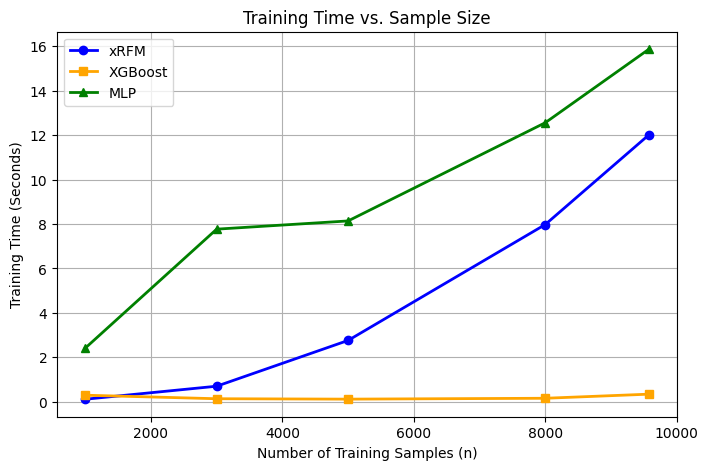

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, xrfm_times, marker='o', label='xRFM', color='blue', linewidth=2)
plt.plot(sample_sizes, xgb_times, marker='s', label='XGBoost', color='orange', linewidth=2)
plt.plot(sample_sizes, mlp_times, marker='^', label='MLP', color='green', linewidth=2)
plt.title('Training Time vs. Sample Size')
plt.xlabel('Number of Training Samples (n)')
plt.ylabel('Training Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()

RMSE Plot

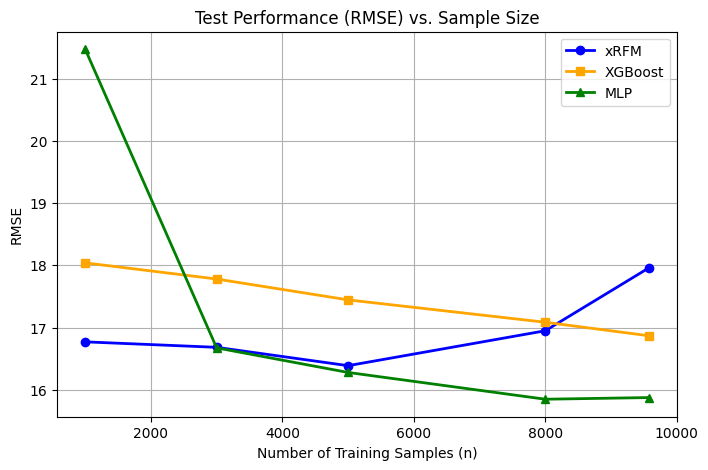

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, xrfm_rmses, marker='o', label='xRFM', color='blue', linewidth=2)
plt.plot(sample_sizes, xgb_rmses, marker='s', label='XGBoost', color='orange', linewidth=2)
plt.plot(sample_sizes, mlp_rmses, marker='^', label='MLP', color='green', linewidth=2)
plt.title('Test Performance (RMSE) vs. Sample Size')
plt.xlabel('Number of Training Samples (n)')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

Inference Time

In [6]:
def get_infer_time_us(model, X_test):
    start = time.time()
    model.predict(X_test)
    end = time.time()
    
    total_seconds = end - start
    us_per_sample = (total_seconds / len(X_test)) * 1_000_000
    return us_per_sample

xrfm_us = get_infer_time_us(model_xrfm, X_test)
xgb_us = get_infer_time_us(model_xgb, X_test)
mlp_us = get_infer_time_us(model_mlp, X_test)

print(f"xRFM Infer (us):    {xrfm_us:.4f}")
print(f"XGBoost Infer (us): {xgb_us:.4f}")
print(f"MLP Infer (us):     {mlp_us:.4f}")

xRFM Infer (us):    20.7903
XGBoost Infer (us): 0.8434
MLP Infer (us):     0.8343
